Capstone Project: Predicting Fantasy Premier League Total Season Points
**By: Chukwuebuka Ozoh**
This notebook walks through data setup, EDA, feature engineering, model building, evaluation.

In [104]:
## 1. Data Setup
# Import necessary libraries and load the dataset

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [105]:
fpl_data = pd.read_csv('C:\\Users\\Chukwuebuka Ozoh\\Downloads\\players.csv')

In [69]:
## 3a. Results Visualizations

# Ensure cost_m and value columns exist
fpl_data['cost_m'] = fpl_data['now_cost'] / 10
fpl_data['value']  = fpl_data['total_points'] / fpl_data['cost_m']

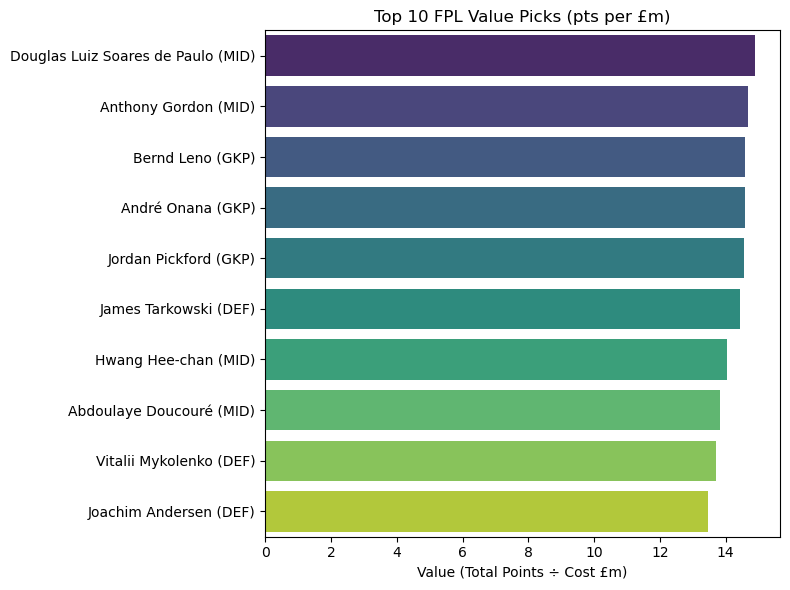

In [70]:
# 1. Top 10 value picks
top10 = fpl_data.sort_values('value', ascending=False).head(10).copy()

# Create a combined label "Name (Pos)"
top10['label'] = top10['name'] + " (" + top10['position'] + ")"

plt.figure(figsize=(8,6))
sns.barplot(
    x='value',
    y='label',
    data=top10,
    palette='viridis'
)
plt.title('Top 10 FPL Value Picks (pts per £m)')
plt.xlabel('Value (Total Points ÷ Cost £m)')
plt.ylabel('')
plt.tight_layout()
plt.show()

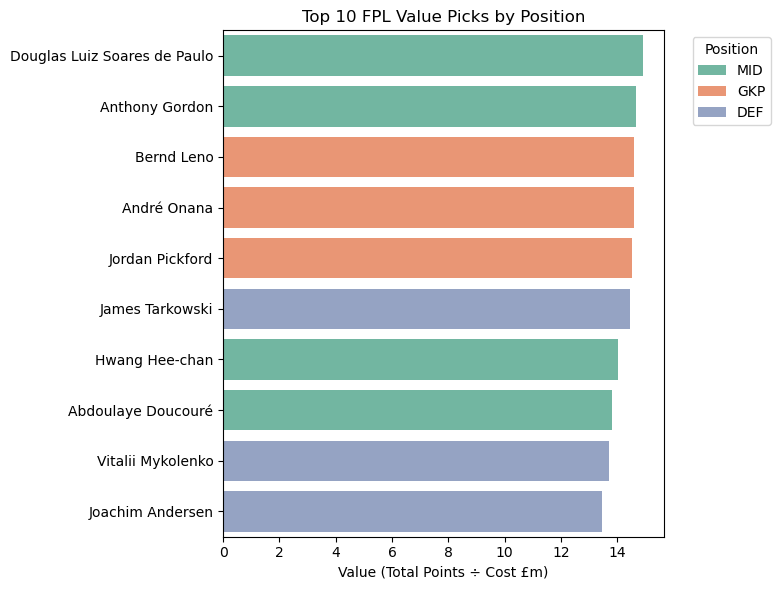

In [71]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='value',
    y='name',
    hue='position',
    data=top10,
    dodge=False,        # prevents splitting bars by hue
    palette='Set2'
)
plt.title('Top 10 FPL Value Picks by Position')
plt.xlabel('Value (Total Points ÷ Cost £m)')
plt.ylabel('')
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

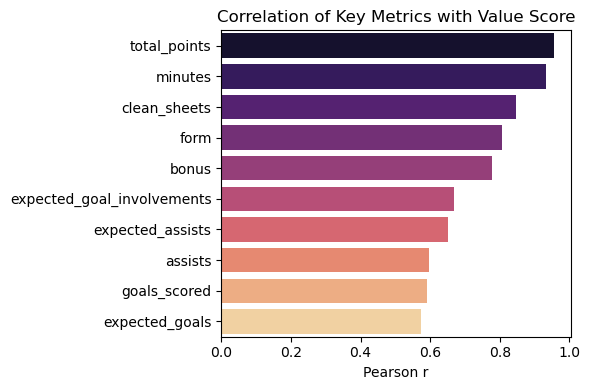

In [72]:
# 2. Correlations with the value metric
corrs = fpl_data[key_metrics].corrwith(fpl_data['value']).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    x=corrs.values,
    y=corrs.index,
    palette='magma'
)
plt.title('Correlation of Key Metrics with Value Score')
plt.xlabel('Pearson r')
plt.ylabel('')
plt.tight_layout()
plt.show()

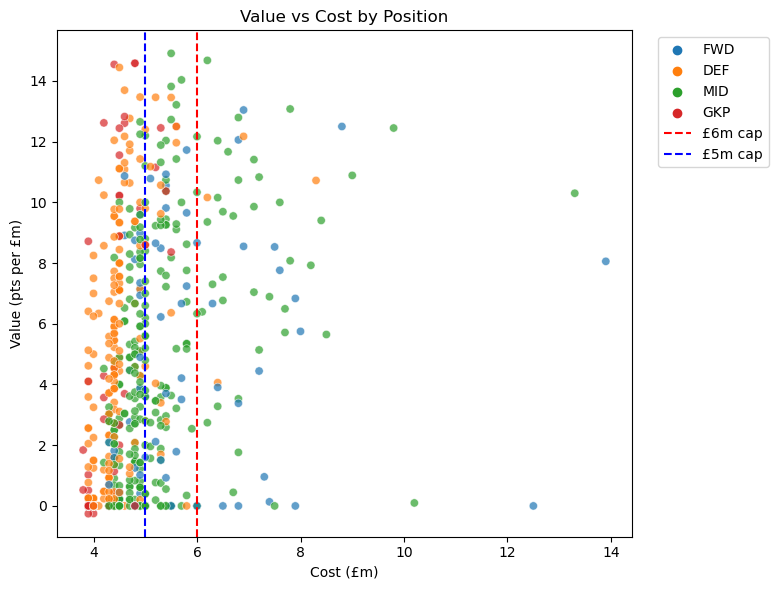

In [73]:
# 3. Scatter: value vs cost_m by position, with cost thresholds
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='cost_m',
    y='value',
    hue='position',
    data=fpl_data,
    alpha=0.7
)
# Add vertical lines at cost = £6m and £5m
for thresh, col in [(6, 'red'), (5, 'blue')]:
    plt.axvline(thresh, color=col, linestyle='--', label=f'£{thresh}m cap')
plt.title('Value vs Cost by Position')
plt.xlabel('Cost (£m)')
plt.ylabel('Value (pts per £m)')
plt.legend(loc='upper right', bbox_to_anchor=(1.25,1))
plt.tight_layout()
plt.show()

In [74]:
# Define key metrics
key_metrics = [
    'minutes', 'goals_scored', 'assists', 'clean_sheets',
    'expected_goals', 'expected_assists', 'expected_goal_involvements',
    'bonus', 'form', 'total_points'
]

In [75]:
# Subset and clean
fpl_data = fpl_data[key_metrics].dropna()
print("Dataset shape:", fpl_data.shape)
print(fpl_data.head())

Dataset shape: (769, 10)
   minutes  goals_scored  assists  clean_sheets  expected_goals  \
0        0             0        0             0            0.00   
1        0             0        0             0            0.00   
2        1             0        1             0            0.00   
3      236             1        3             1            1.20   
4     1284             1        0             5            0.93   

   expected_assists  expected_goal_involvements  bonus  form  total_points  
0              0.00                        0.00      0   0.0             0  
1              0.00                        0.00      0   0.0             0  
2              0.00                        0.00      0   0.0             4  
3              0.35                        1.55      0   0.0            21  
4              0.22                        1.15      4   4.5            56  


In [76]:
# Check for missing values
pd.set_option('display.max_rows', None)
fpl_data.isnull().sum()

minutes                       0
goals_scored                  0
assists                       0
clean_sheets                  0
expected_goals                0
expected_assists              0
expected_goal_involvements    0
bonus                         0
form                          0
total_points                  0
dtype: int64

In [77]:
# Keep only players who played at least once
fpl_data = fpl_data[fpl_data['minutes'] > 0].copy()

# Now compute per-90 normally
fpl_data['xG_per_90'] = fpl_data['expected_goals'] / (fpl_data['minutes'] / 90)
fpl_data['xA_per_90'] = fpl_data['expected_assists'] / (fpl_data['minutes'] / 90)

In [78]:
## 2. Exploratory Data Analysis (5 Visualizations)
# We'll create 5 key plots to understand the data

# 1. Distribution of Total Points
def plot_distribution():
    plt.figure(figsize=(6,4))
    sns.histplot(fpl_data['total_points'], bins=30, kde=True, color='skyblue')
    plt.title('Distribution of Total Season Points')
    plt.xlabel('Total Points')
    plt.ylabel('Count')
    plt.show()

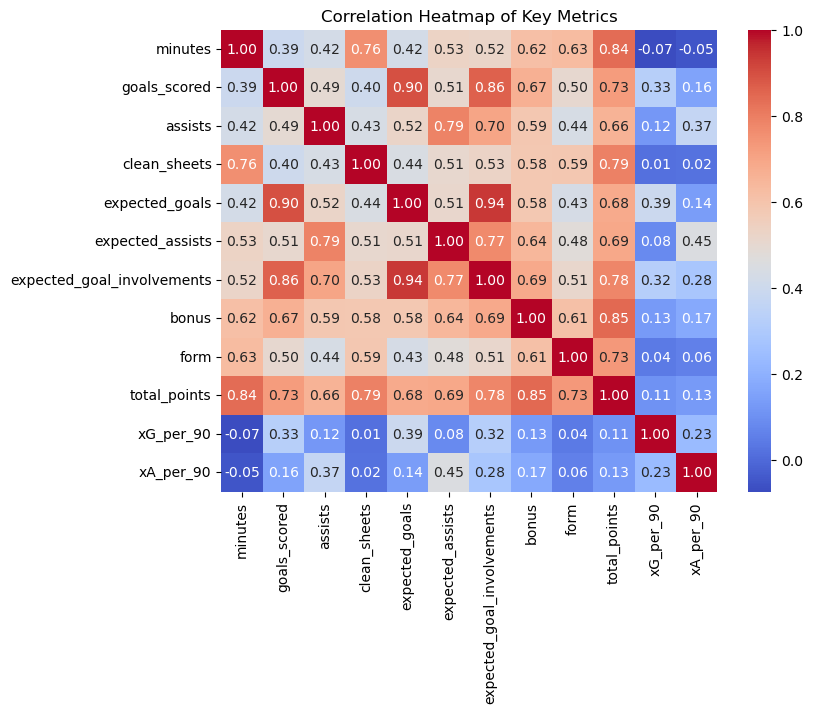

In [79]:
# 2. Correlation Heatmap among key metrics
plt.figure(figsize=(8,6))
sns.heatmap(fpl_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Key Metrics')
plt.show()

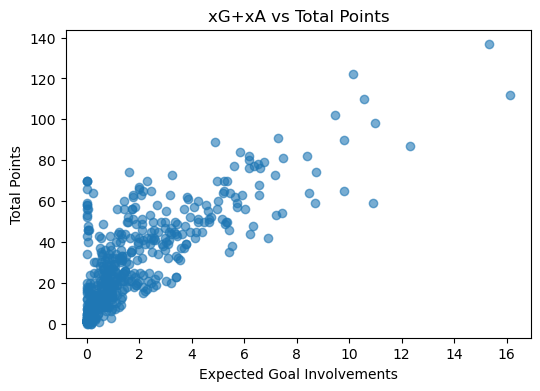

In [80]:
# 3. Scatter plot: Expected Goal Involvements vs Total Points
plt.figure(figsize=(6,4))
plt.scatter(fpl_data['expected_goal_involvements'], fpl_data['total_points'], alpha=0.6)
plt.title('xG+xA vs Total Points')
plt.xlabel('Expected Goal Involvements')
plt.ylabel('Total Points')
plt.show()

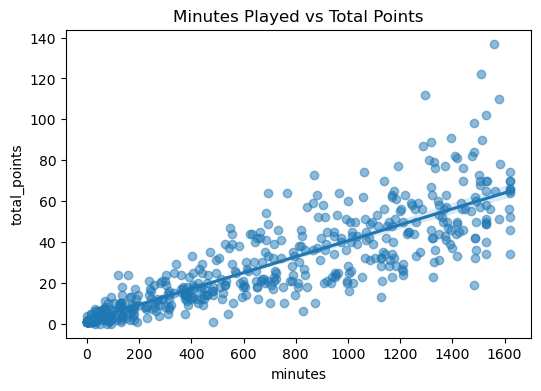

In [81]:
# 4. Scatter plot: Minutes Played vs Total Points
plt.figure(figsize=(6,4))
sns.regplot(x='minutes', y='total_points', data=fpl_data, scatter_kws={'alpha':0.5})
plt.title('Minutes Played vs Total Points')
plt.show()

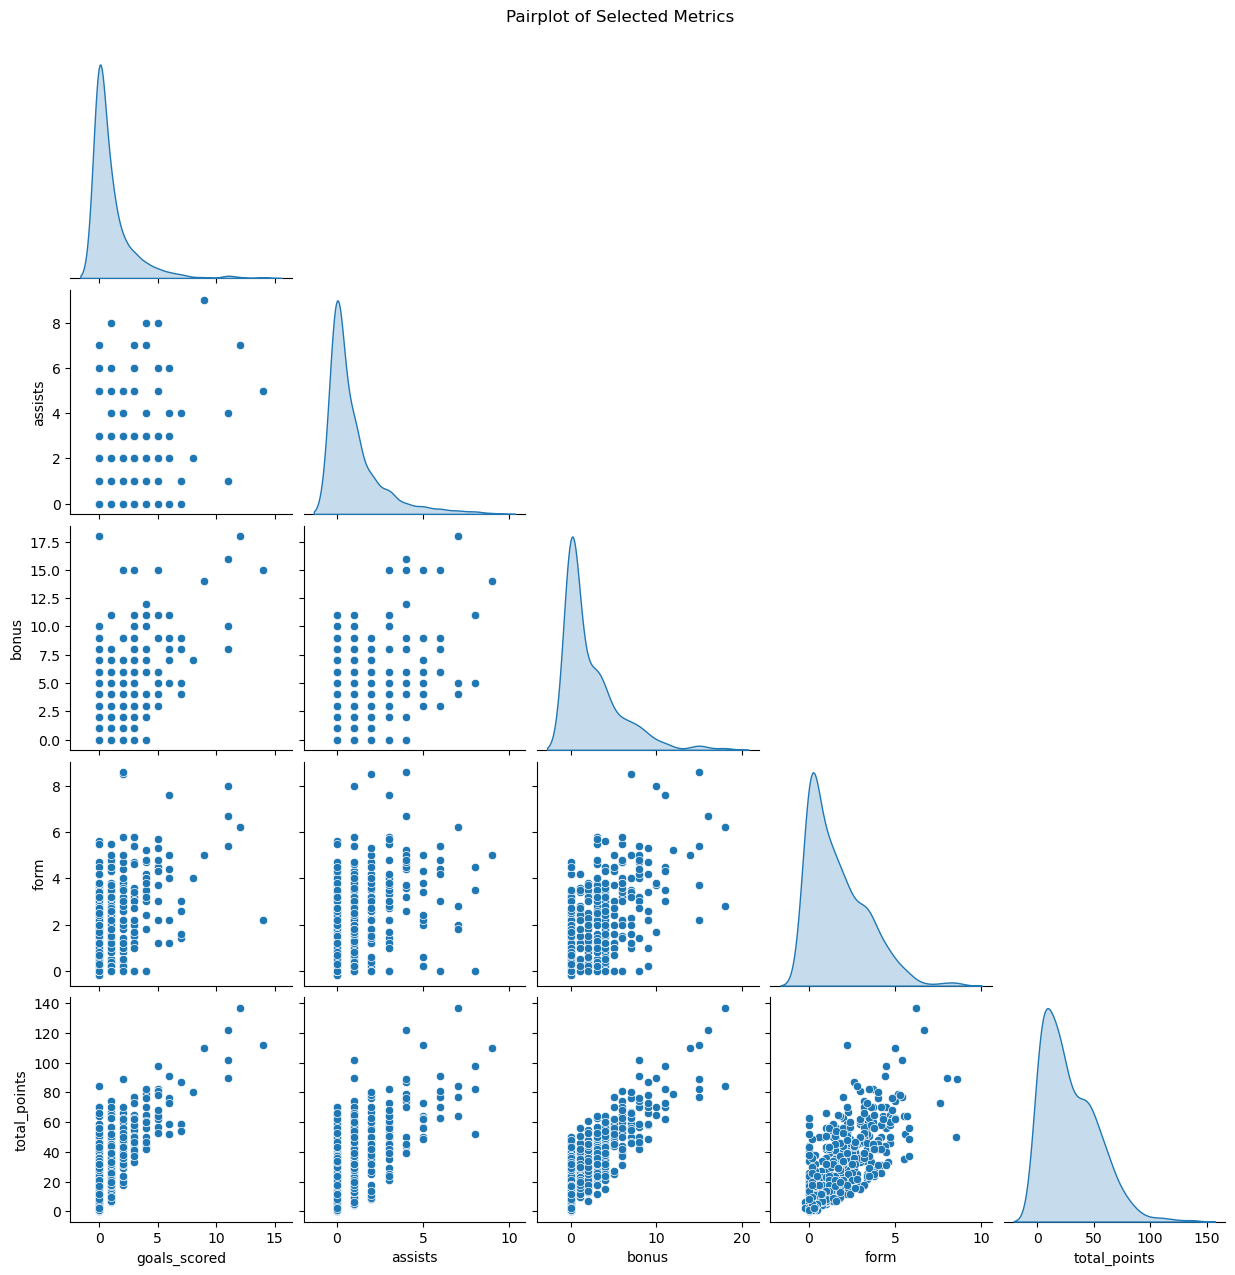

In [82]:
# 5. Pairplot of selected features
sns.pairplot(fpl_data[['goals_scored','assists','bonus','form','total_points']], corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Selected Metrics', y=1.02)
plt.show()

In [83]:
## 3. Feature Engineering
# Although we use only key metrics, we can add interactions or per-90 features

# %%
# Add goal contributions (goals + assists)
fpl_data['goal_contributions'] = fpl_data['goals_scored'] + fpl_data['assists']
# Per-90 features
fpl_data['xG_per_90'] = fpl_data['expected_goals'] / (fpl_data['minutes'] / 90)
fpl_data['xA_per_90'] = fpl_data['expected_assists'] / (fpl_data['minutes'] / 90)

In [84]:
# Update feature list
features = [f for f in key_metrics if f!='total_points'] + ['goal_contributions','xG_per_90','xA_per_90']
print("Final features:", features)

Final features: ['minutes', 'goals_scored', 'assists', 'clean_sheets', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'bonus', 'form', 'goal_contributions', 'xG_per_90', 'xA_per_90']


In [85]:
## 4. Model Building and Training
# We'll train Linear Regression, Random Forest, and XGBoost

In [86]:
# Prepare X and y
y = fpl_data['total_points']
X = fpl_data[features]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
# Function to evaluate model
def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    print(f"{name} results:")
    print(f"  R^2: {r2_score(y_test, y_pred):.3f}")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
    print(f"RMSE: {rmse:.2f}")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred):.2f}\n")

In [89]:
# 4a. Linear Regression
pipe_lr = Pipeline([('scaler',StandardScaler()),('lr',LinearRegression())])
pipe_lr.fit(X_train, y_train)
evaluate_model('Linear Regression', pipe_lr)

Linear Regression results:
  R^2: 0.975
RMSE: 3.92
  MAE: 2.81



In [90]:
# 4b. Random Forest Regressor
pipe_rf = Pipeline([('scaler',StandardScaler()),('rf',RandomForestRegressor(n_estimators=100, random_state=42))])
pipe_rf.fit(X_train, y_train)
evaluate_model('Random Forest', pipe_rf)

Random Forest results:
  R^2: 0.961
RMSE: 4.84
  MAE: 3.32



In [91]:
# 4c. XGBoost Regressor
pipe_xgb = Pipeline([('scaler',StandardScaler()),('xgb',XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42))])
pipe_xgb.fit(X_train, y_train)
evaluate_model('XGBoost', pipe_xgb)

XGBoost results:
  R^2: 0.963
RMSE: 4.74
  MAE: 3.41



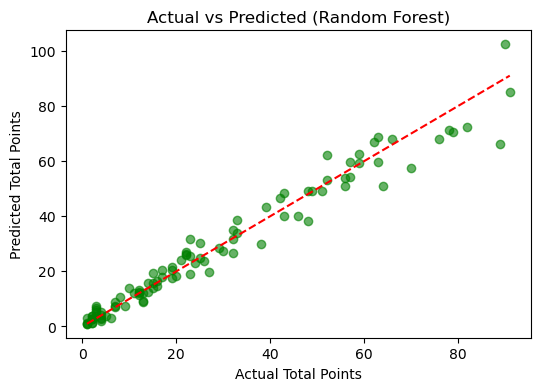

In [113]:
## 5. Visualizing Predictions (Best Model)
# Assume Random Forest is best

# %%
best_model = pipe_rf
y_pred = best_model.predict(X_test)
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel('Actual Total Points')
plt.ylabel('Predicted Total Points')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()

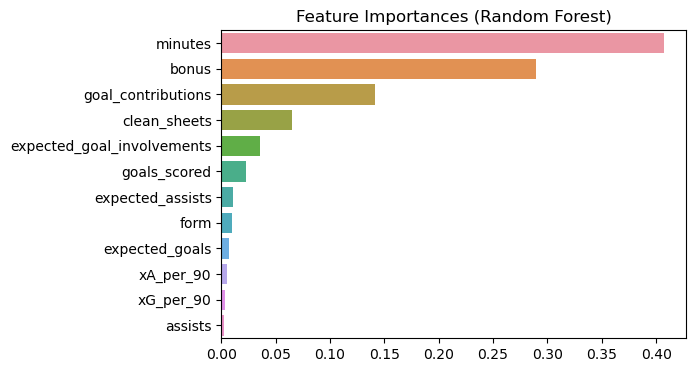

In [98]:
## 6. Feature Importance (Random Forest)

# %%
importances = best_model.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importances (Random Forest)')
plt.show()


In [58]:
print(fpl_data.columns.tolist())

['minutes', 'goals_scored', 'assists', 'clean_sheets', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'bonus', 'form', 'total_points', 'goal_contributions', 'xG_per_90', 'xA_per_90']


2025-05-01 05:02:01.602 No runtime found, using MemoryCacheStorageManager
2025-05-01 05:02:01.606 No runtime found, using MemoryCacheStorageManager
2025-05-01 05:02:01.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 05:02:01.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()

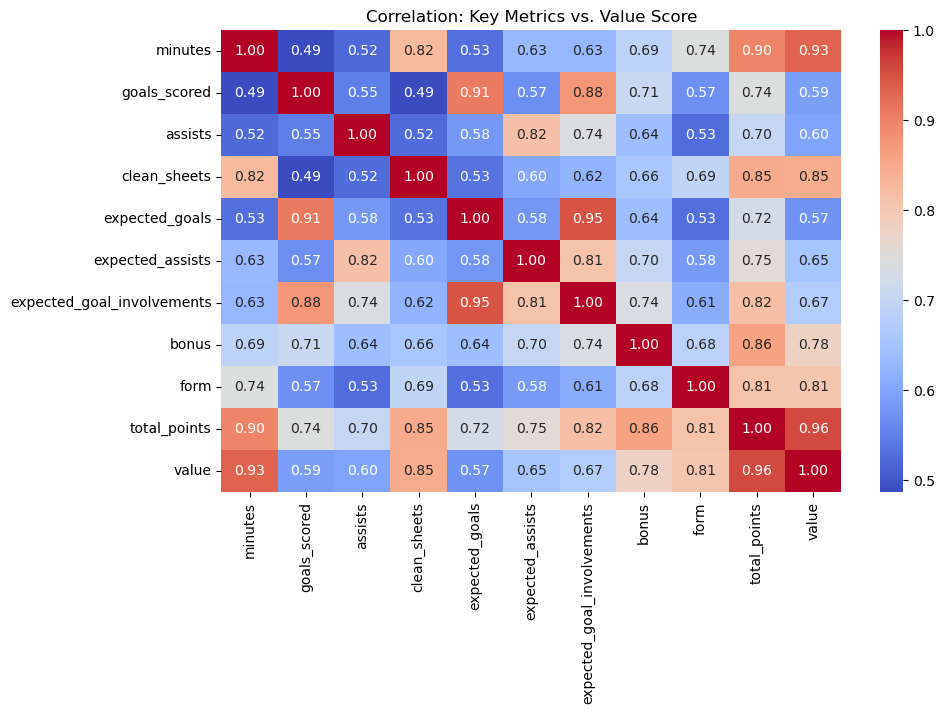

In [108]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------
# 1. Load & Prepare Data
# ----------------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv('C:\\Users\\Chukwuebuka Ozoh\\Downloads\\players.csv')  # adjust path
    if 'now_cost' not in df.columns:
        st.error("Dataset must contain a 'now_cost' column.")
        st.stop()
    df['cost_m'] = df['now_cost'] / 10.0
    df['value']  = df['total_points'] / df['cost_m']
    return df

fpl_data = load_data()

# Define key metrics
key_metrics = [
    'minutes', 'goals_scored', 'assists', 'clean_sheets',
    'expected_goals', 'expected_assists', 'expected_goal_involvements',
    'bonus', 'form', 'total_points'
]

# ----------------------------------------
# 2. Sidebar Filters
# ----------------------------------------
st.sidebar.header("🔧 Filters")
positions = sorted(fpl_data['position'].unique())
sel_pos = st.sidebar.multiselect("Position", options=positions, default=positions)

min_cost = float(fpl_data['cost_m'].min())
max_cost = float(fpl_data['cost_m'].max())
sel_cost = st.sidebar.slider("Cost Range (£m)", min_cost, max_cost, (min_cost, max_cost))

top_n = st.sidebar.number_input("Show Top N Picks", min_value=5, max_value=50, value=10)

# ----------------------------------------
# 3. Filtered Data & Top Picks
# ----------------------------------------
filtered = fpl_data[
    (fpl_data['position'].isin(sel_pos)) &
    (fpl_data['cost_m'] >= sel_cost[0]) &
    (fpl_data['cost_m'] <= sel_cost[1])
]
top_picks = filtered.sort_values('value', ascending=False).head(int(top_n))

# ----------------------------------------
# 4. Main Display
# ----------------------------------------
st.set_page_config(page_title="FPL Value Picks Dashboard", layout="wide")
st.title("💡 FPL Cost-Effective Stars")
st.markdown("Use historical performance metrics to identify the season's best value picks.")

st.subheader(f"🏆 Top {top_n} Value Picks")

# Build display columns without duplicating total_points
base_cols = ['name', 'team', 'position', 'cost_m', 'value']
metrics_without_target = [m for m in key_metrics if m != 'total_points']
display_cols = base_cols + ['total_points'] + metrics_without_target

st.dataframe(
    top_picks[display_cols]
        .rename(columns={
            'cost_m':'cost (£m)',
            'value':'pts per £m'
        }),
    height=400
)

# ----------------------------------------
# 5. EDA Visualization
# ----------------------------------------
st.subheader("📈 Correlation Heatmap")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    fpl_data[key_metrics + ['value']].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", ax=ax
)
ax.set_title("Correlation: Key Metrics vs. Value Score")
st.pyplot(fig)

# ----------------------------------------
# 6. Footer
# ----------------------------------------
st.markdown("---")
st.caption("Built by Chukwuebuka Ozoh | Capstone: Predicting FPL Performance | 2023–24 Season")